# Phase 1 — Lesson 4: Time Series Components
## Level, Trend, Seasonality, and Noise

Roadmap check:

- Previous lesson: Phase 1 — Lesson 3 — Time Series Visualization.
- Current lesson: Phase 1 — Lesson 4 — Time Series Components.
- We will not use forecasting models, smoothing, stationarity, decomposition, or ARIMA in this notebook.

## Lesson objectives

By the end of this lesson, you should be able to identify:

1. Level
2. Trend
3. Seasonality
4. Noise / random variation

Simple idea:

$$
\text{Time Series} = \text{Level} + \text{Trend} + \text{Seasonality} + \text{Noise}
$$

## 1. Level

The **level** is the typical value around which the time series moves.

Example: if daily website visitors are usually around 100, then the approximate level is 100.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

level_data = {
    "Date": pd.date_range(start="2026-04-01", periods=10, freq="D"),
    "Visitors": [98, 102, 100, 101, 97, 103, 99, 101, 100, 102]
}

level_df = pd.DataFrame(level_data)
level_df = level_df.set_index("Date")
level_df

,Visitors
Date,
2026-04-01,98
2026-04-02,102
2026-04-03,100
2026-04-04,101
2026-04-05,97
2026-04-06,103
2026-04-07,99
2026-04-08,101
2026-04-09,100


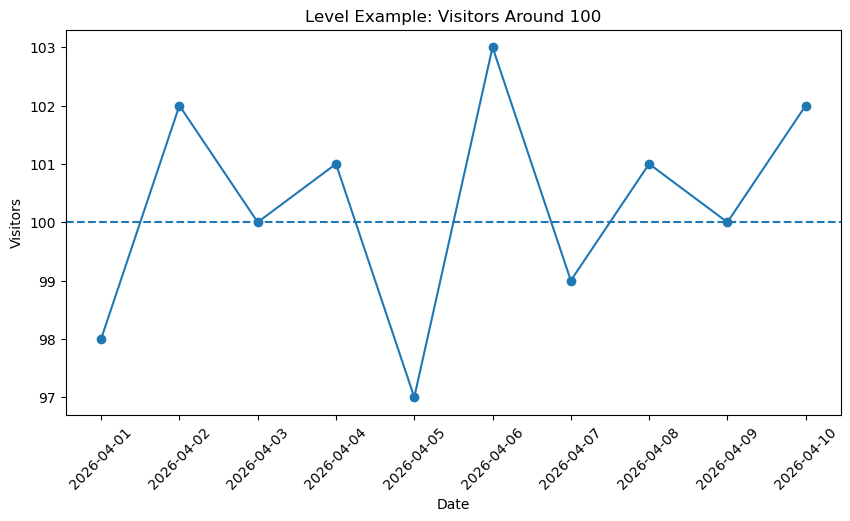

In [2]:
plt.figure(figsize=(10, 5))
plt.plot(level_df.index, level_df["Visitors"], marker="o")
plt.axhline(100, linestyle="--")
plt.xlabel("Date")
plt.ylabel("Visitors")
plt.title("Level Example: Visitors Around 100")
plt.xticks(rotation=45)
plt.show()

### Exercise 1

Sales values:

```python
sales = [490, 510, 505, 495, 515, 500, 485, 505]
```

What is the approximate level?

Write your answer before checking the solution.

In [3]:
# Write your answer here as a comment
# Approximate level =

**Solution:** The approximate level is **500** because most values move around 500.

## 2. Trend

The **trend** is the long-term direction of the time series.

- Uptrend: values generally increase over time.
- Downtrend: values generally decrease over time.

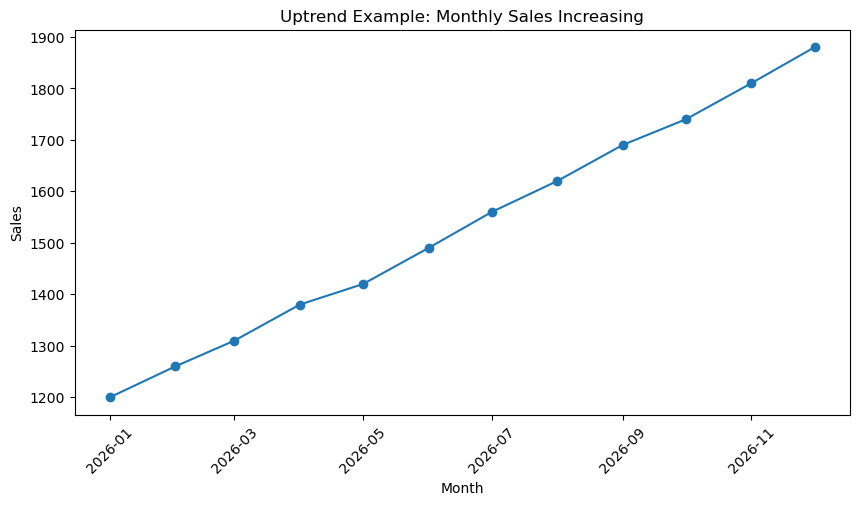

In [4]:
months = pd.date_range(start="2026-01-01", periods=12, freq="MS")
sales = [1200, 1260, 1310, 1380, 1420, 1490, 1560, 1620, 1690, 1740, 1810, 1880]

sales_df = pd.DataFrame({"Sales": sales}, index=months)

plt.figure(figsize=(10, 5))
plt.plot(sales_df.index, sales_df["Sales"], marker="o")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Uptrend Example: Monthly Sales Increasing")
plt.xticks(rotation=45)
plt.show()

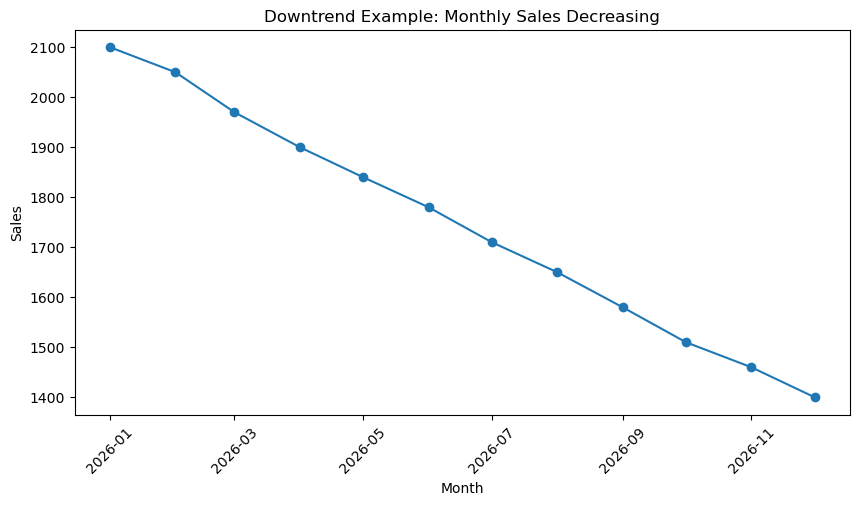

In [5]:
down_sales = [2100, 2050, 1970, 1900, 1840, 1780, 1710, 1650, 1580, 1510, 1460, 1400]
down_df = pd.DataFrame({"Sales": down_sales}, index=months)

plt.figure(figsize=(10, 5))
plt.plot(down_df.index, down_df["Sales"], marker="o")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Downtrend Example: Monthly Sales Decreasing")
plt.xticks(rotation=45)
plt.show()

### Exercise 2

Values:

```python
[2100, 2050, 1970, 1900, 1840, 1780, 1710]
```

Is this an uptrend, downtrend, or no clear trend?

In [6]:
# Write your answer here
# Trend type =

**Solution:** This is a **downtrend** because the general direction decreases over time.

## 3. Seasonality

**Seasonality** is a repeated pattern that happens at a regular interval.

Examples:

- Website visitors increase every weekend.
- Ice cream sales increase every summer.
- Temperature follows a yearly pattern.

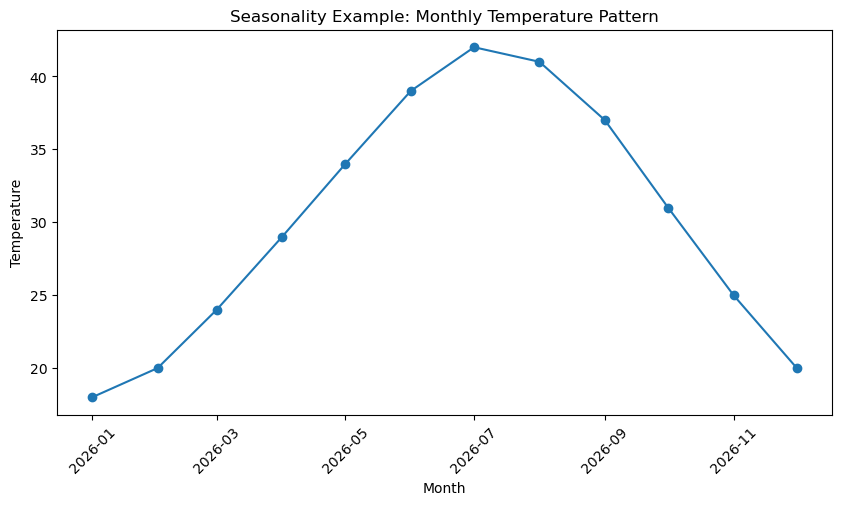

In [7]:
temperature = [18, 20, 24, 29, 34, 39, 42, 41, 37, 31, 25, 20]
temp_df = pd.DataFrame({"Temperature": temperature}, index=months)

plt.figure(figsize=(10, 5))
plt.plot(temp_df.index, temp_df["Temperature"], marker="o")
plt.xlabel("Month")
plt.ylabel("Temperature")
plt.title("Seasonality Example: Monthly Temperature Pattern")
plt.xticks(rotation=45)
plt.show()

### Exercise 3

A website gets more visitors every Friday and Saturday, then fewer visitors every Monday.

Is this **seasonality** or **noise**? Why?

In [8]:
# Write your answer here
# Answer = 
# Reason =

**Solution:** This is **seasonality** because the pattern repeats every week.

## 4. Noise / Random Variation

**Noise** is random movement that does not follow a clear repeated pattern.

Noise is normal in real data.

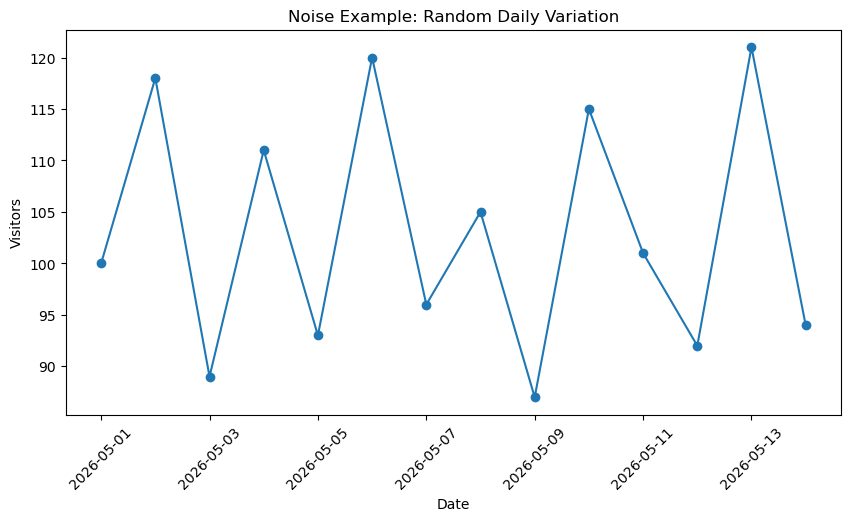

In [9]:
noise_dates = pd.date_range(start="2026-05-01", periods=14, freq="D")
noise_visitors = [100, 118, 89, 111, 93, 120, 96, 105, 87, 115, 101, 92, 121, 94]
noise_df = pd.DataFrame({"Visitors": noise_visitors}, index=noise_dates)

plt.figure(figsize=(10, 5))
plt.plot(noise_df.index, noise_df["Visitors"], marker="o")
plt.xlabel("Date")
plt.ylabel("Visitors")
plt.title("Noise Example: Random Daily Variation")
plt.xticks(rotation=45)
plt.show()

### Exercise 4

If sales suddenly increase on one day because a famous person mentioned the product, is that trend, seasonality, or noise?

In [10]:
# Write your answer here
# Answer =

**Solution:** Usually **noise** or a special event. It is not trend unless it continues over time, and it is not seasonality unless it repeats regularly.

## 5. Combined Practical Dataset

Now we create one dataset that contains:

- Level around 100
- Uptrend
- Weekly seasonality
- Noise

In [11]:
import numpy as np

np.random.seed(7)

dates = pd.date_range(start="2026-04-01", periods=60, freq="D")

level = 100
trend = np.arange(60) * 1.2
weekly_pattern = np.array([0, 5, 3, 8, 15, 30, 25] * 9)[:60]
noise = np.random.normal(0, 6, 60)

visitors = level + trend + weekly_pattern + noise
visitors = visitors.round().astype(int)

website = pd.DataFrame({"Visitors": visitors}, index=dates)
website.index.name = "Date"

website.head()

,Visitors
Date,
2026-04-01,110
2026-04-02,103
2026-04-03,106
2026-04-04,114
2026-04-05,115


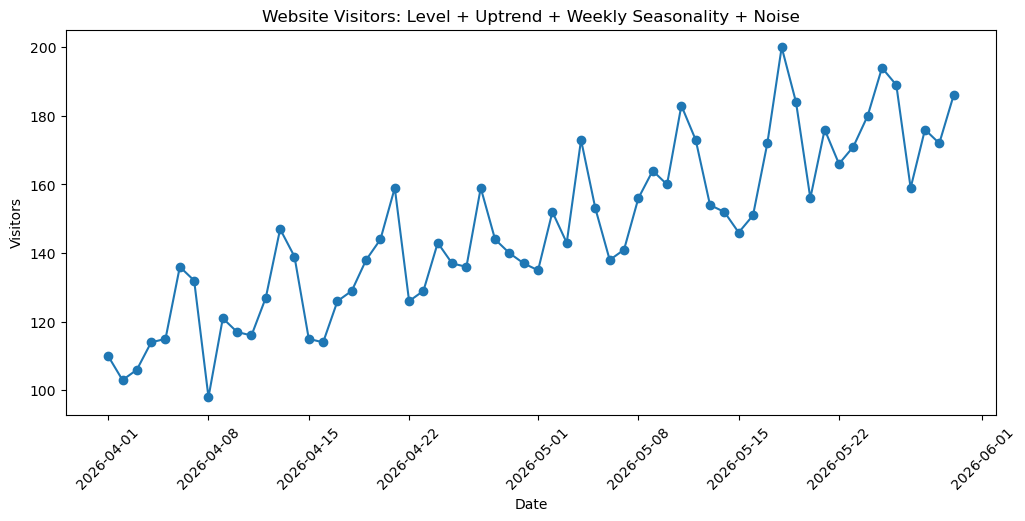

In [12]:
plt.figure(figsize=(12, 5))
plt.plot(website.index, website["Visitors"], marker="o")
plt.xlabel("Date")
plt.ylabel("Visitors")
plt.title("Website Visitors: Level + Uptrend + Weekly Seasonality + Noise")
plt.xticks(rotation=45)
plt.show()

## How to visually identify the components

- **Level:** the series starts around 100 visitors.
- **Uptrend:** the general position of the line increases from left to right.
- **Seasonality:** repeated weekly rises and falls.
- **Noise:** small irregular movements that do not repeat exactly.

## Trend vs Seasonality

| Trend | Seasonality |
|---|---|
| Long-term direction | Repeated pattern |
| Does not need to repeat | Must repeat at a regular interval |
| Example: sales increase over 12 months | Example: sales rise every weekend |

## Seasonality vs Noise

| Seasonality | Noise |
|---|---|
| Repeats regularly | Does not repeat regularly |
| Timing is predictable | Timing is usually not predictable |
| Example: higher sales every weekend | Example: one random spike |

## Final Practice Task

Create a daily sales dataset for 30 days. It should include:

1. A level around 200 sales.
2. A small uptrend.
3. A weekly seasonal pattern where weekends are higher.
4. A little random noise.
5. A Matplotlib plot.

Then answer:

1. What is the approximate level?
2. Is there an uptrend, downtrend, or no clear trend?
3. What repeated pattern do you notice?
4. Which parts of the graph look like noise?

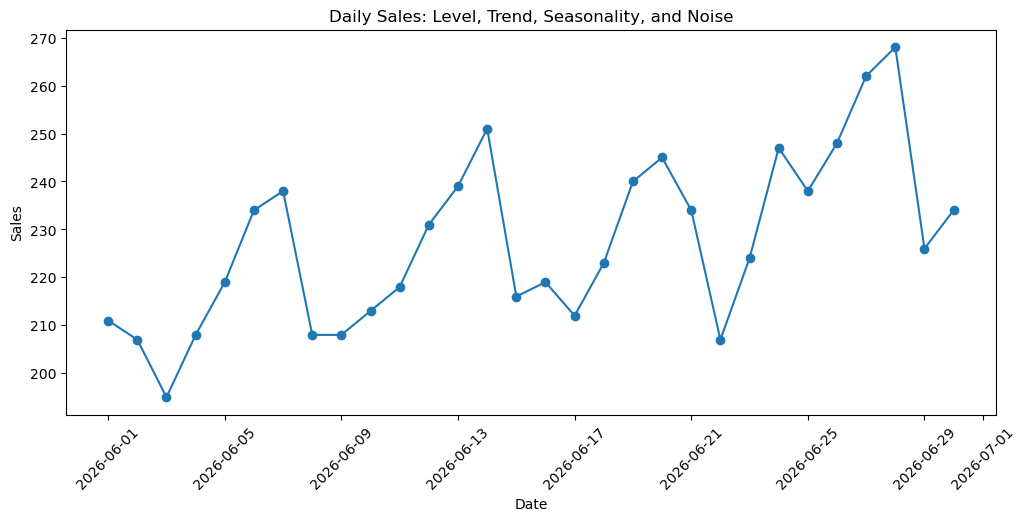

In [13]:
# Final practice starter code
np.random.seed(10)

dates = pd.date_range(start="2026-06-01", periods=30, freq="D")
level = 200
trend = np.arange(30) * 1
weekly_pattern = np.array([0, 0, 5, 5, 10, 35, 30] * 5)[:30]
noise = np.random.normal(0, 8, 30)

sales = level + trend + weekly_pattern + noise
sales = sales.round().astype(int)

sales_df = pd.DataFrame({"Sales": sales}, index=dates)

plt.figure(figsize=(12, 5))
plt.plot(sales_df.index, sales_df["Sales"], marker="o")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Daily Sales: Level, Trend, Seasonality, and Noise")
plt.xticks(rotation=45)
plt.show()

## Lesson 4 Summary / Cheat Sheet

| Concept | Simple definition | Visual clue |
|---|---|---|
| Level | Typical value | Data moves around this value |
| Uptrend | Long-term increase | Line generally rises left to right |
| Downtrend | Long-term decrease | Line generally falls left to right |
| Seasonality | Repeated pattern | Same shape repeats regularly |
| Noise | Random variation | Irregular movements with no clear repeat |

Key question when reading a graph:

**What is the level? Is there a trend? Is there a repeated pattern? What movement looks random?**

## Practical Exercise 3

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

practice_data = {
    "Date": pd.date_range(
        start="2026-06-01",
        periods=14,
        freq="D"
    ),

    "Visitors": [
        100, 110, 105, 120, 130, 125, 140,
        145, 150, 155, 160, 170, 165, 180
    ],

    "Sales": [
        500, 520, 510, 560, 600, 590, 650,
        670, 690, 720, 750, 790, 780, 850
    ],

    "Ad_Spend": [
        100, 100, 105, 110, 115, 115, 120,
        125, 125, 130, 135, 140, 140, 145
    ]
}

practice_df = pd.DataFrame(practice_data)

practice_df["Date"] = pd.to_datetime(
    practice_df["Date"]
)

practice_df = practice_df.set_index("Date")

practice_df

,Visitors,Sales,Ad_Spend
Date,,,
2026-06-01,100,500,100
2026-06-02,110,520,100
2026-06-03,105,510,105
2026-06-04,120,560,110
2026-06-05,130,600,115
2026-06-06,125,590,115
2026-06-07,140,650,120
2026-06-08,145,670,125
2026-06-09,150,690,125


In [16]:
practice_df.head()

,Visitors,Sales,Ad_Spend
Date,,,
2026-06-01,100,500,100
2026-06-02,110,520,100
2026-06-03,105,510,105
2026-06-04,120,560,110
2026-06-05,130,600,115


In [17]:
practice_df.shape

(14, 3)

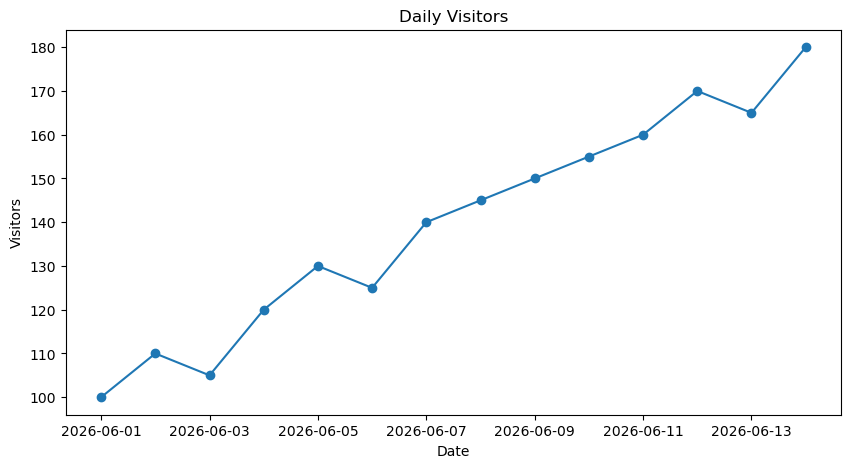

In [18]:
plt.figure(figsize=(10, 5))

plt.plot(
    practice_df.index,
    practice_df["Visitors"],
    marker="o"
)

plt.xlabel("Date")
plt.ylabel("Visitors")
plt.title("Daily Visitors")

plt.show()

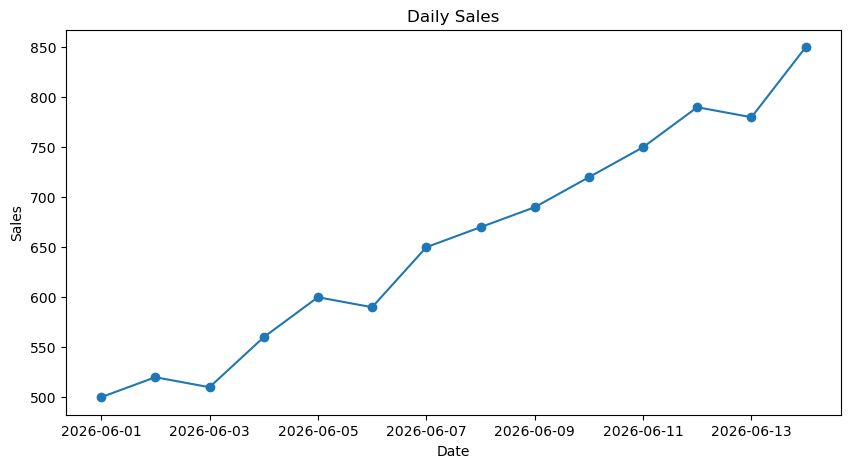

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(
    practice_df.index,
    practice_df["Sales"],
    marker="o"
)

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Daily Sales")

plt.show()

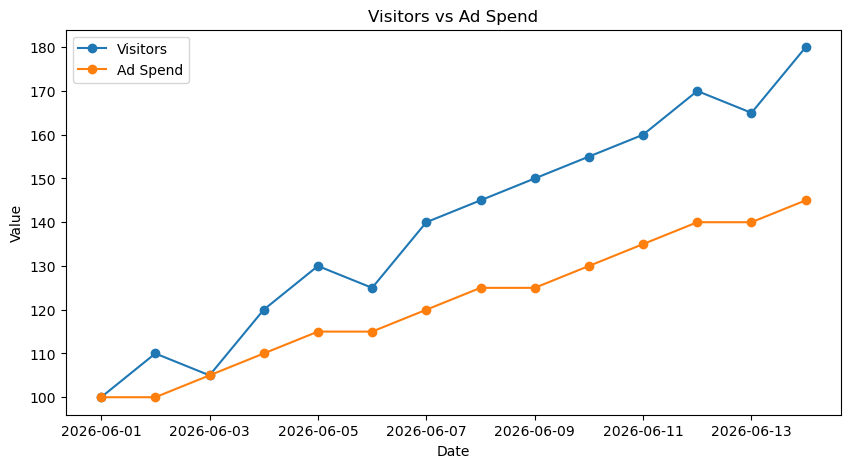

In [20]:
plt.figure(figsize=(10, 5))

plt.plot(
    practice_df.index,
    practice_df["Visitors"],
    marker="o",
    label="Visitors"
)

plt.plot(
    practice_df.index,
    practice_df["Ad_Spend"],
    marker="o",
    label="Ad Spend"
)

plt.xlabel("Date")
plt.ylabel("Value")

plt.title(
    "Visitors vs Ad Spend"
)

plt.legend()

plt.show()

In [21]:
practice_df.corr()

,Visitors,Sales,Ad_Spend
Visitors,1.000000,0.995751,0.988925
Sales,0.995751,1.000000,0.992852
Ad_Spend,0.988925,0.992852,1.000000
